# Project A — Steps 4-7 + Power BI Export (combined)

Single-notebook version: distribution fitting -> (Q,R) model -> PuLP optimizer -> scenarios -> Monte Carlo -> Power BI CSV export, all in one kernel session. This avoids the cross-notebook NameError you'd hit running 02 and 03 as separate files without sharing a kernel.

Run all cells top to bottom.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

DB_PATH = "dataco_staging.db"

## 0. Assumptions
Mirrors `dim_model_assumptions` in the SQL schema — every synthetic number lives here, in one place, with a stated basis.

In [2]:
HOLDING_COST_PCT_ANNUAL = 0.20          # industry-typical 15-25% annual holding cost
DEFAULT_SERVICE_LEVEL = 0.95
PRIORITY_SERVICE_LEVEL = 0.99           # top-3 volume regions get the higher target
BUDGET_MULTIPLIER = 1.10                # optimizer gets 10% more than the naive baseline spend
STOCKOUT_PENALTY_PER_UNIT_FACTOR = 3.0  # stockout costs ~3x holding cost per unit -- a common retail rule of thumb, stated explicitly so it can be challenged/defended in interview

## 1. Load data (real staging DB, or synthetic fallback)

In [3]:
def load_raw():
    if Path(DB_PATH).exists():
        conn = sqlite3.connect(DB_PATH)
        try:
            df = pd.read_sql(
                "SELECT category_name, order_region, order_item_quantity, "
                "product_price, days_for_shipping_real, days_for_shipment_scheduled, "
                "order_date FROM stg_dataco_raw",
                conn,
                parse_dates=["order_date"],
            )
            conn.close()
            print(f"Loaded {len(df):,} rows from {DB_PATH}")
            return df
        except Exception as e:
            conn.close()
            print(f"Could not read staging DB ({e}) -- falling back to synthetic demo data.")
    else:
        print(f"{DB_PATH} not found -- using synthetic demo data so the pipeline is runnable now.")

    # Synthetic fallback WITH deliberate cost/volatility heterogeneity across
    # categories -- real retail categories genuinely differ this way (cheap
    # erratic accessories vs. expensive stable equipment), and the optimizer
    # only has a real decision to make when that heterogeneity exists.
    regions = ["Western Europe", "Southeast Asia", "South America", "Central America", "East Africa"]
    category_profiles = {
        "Cleats":            {"price_range": (15, 40),   "demand_lambda": 8},   # cheap, volatile
        "Fishing":           {"price_range": (10, 30),   "demand_lambda": 10},  # cheap, volatile
        "Camping & Hiking":  {"price_range": (80, 150),  "demand_lambda": 4},   # mid-cost, moderate
        "Water Sports":      {"price_range": (60, 120),  "demand_lambda": 4},   # mid-cost, moderate
        "Golf Bags":         {"price_range": (200, 350), "demand_lambda": 2},   # expensive, stable
    }
    n_per_cat = 4000
    rows = []
    for cat, prof in category_profiles.items():
        cat_regions = np.random.choice(regions, n_per_cat)
        qty = np.random.poisson(prof["demand_lambda"], n_per_cat) + 1
        price = np.round(np.random.uniform(*prof["price_range"], n_per_cat), 2)
        sched = np.random.choice([2, 4, 6], n_per_cat)
        dates = pd.to_datetime("2023-01-01") + pd.to_timedelta(np.random.randint(0, 700, n_per_cat), unit="D")
        rows.append(pd.DataFrame({
            "category_name": cat, "order_region": cat_regions, "order_item_quantity": qty,
            "product_price": price, "days_for_shipment_scheduled": sched, "order_date": dates,
        }))
    df = pd.concat(rows, ignore_index=True)
    n = len(df)
    df["days_for_shipping_real"] = (
        df["days_for_shipment_scheduled"] + np.random.poisson(1.2, n) - np.random.binomial(1, 0.3, n)
    ).clip(lower=1)
    return df

raw_df = load_raw()
raw_df.head()

Loaded 180,519 rows from dataco_staging.db


,category_name,order_region,order_item_quantity,product_price,days_for_shipping_real,days_for_shipment_scheduled,order_date
0,Sporting Goods,Southeast Asia,1,327.75,3,4,2018-01-31 22:56:00
1,Sporting Goods,South Asia,1,327.75,5,4,2018-01-13 12:27:00
2,Sporting Goods,South Asia,1,327.75,4,4,2018-01-13 12:06:00
3,Sporting Goods,Oceania,1,327.75,3,4,2018-01-13 11:45:00
4,Sporting Goods,Oceania,1,327.75,2,4,2018-01-13 11:24:00


## 2. Build (category, region) weekly demand + lead-time stats
This is our SKU-warehouse grain for the demo.

In [4]:
raw_df["week"] = raw_df["order_date"].dt.to_period("W").dt.start_time
raw_df["lead_time_dev"] = raw_df["days_for_shipping_real"] - raw_df["days_for_shipment_scheduled"]

weekly_demand = (
    raw_df.groupby(["category_name", "order_region", "week"])["order_item_quantity"]
    .sum()
    .reset_index()
)

pair_stats = (
    weekly_demand.groupby(["category_name", "order_region"])["order_item_quantity"]
    .agg(mean_weekly_demand="mean", std_weekly_demand="std", n_weeks="count")
    .reset_index()
)

lead_time_stats = (
    raw_df.groupby(["category_name", "order_region"])
    .agg(
        mean_lead_time=("days_for_shipment_scheduled", "mean"),
        mean_lead_time_dev=("lead_time_dev", "mean"),
        std_lead_time_dev=("lead_time_dev", "std"),
        unit_cost=("product_price", "mean"),
        total_qty=("order_item_quantity", "sum"),
    )
    .reset_index()
)

pair_df = pair_stats.merge(lead_time_stats, on=["category_name", "order_region"])
pair_df["std_weekly_demand"] = pair_df["std_weekly_demand"].fillna(pair_df["mean_weekly_demand"] * 0.3)
pair_df["std_lead_time_dev"] = pair_df["std_lead_time_dev"].fillna(1.0)

# Drop pairs with too little data to model reliably (mirrors Check 7)
MIN_WEEKS = 8
before = len(pair_df)
pair_df = pair_df[pair_df["n_weeks"] >= MIN_WEEKS].reset_index(drop=True)
print(f"Kept {len(pair_df)}/{before} category-region pairs with >= {MIN_WEEKS} weeks of data")
pair_df.head()

Kept 497/691 category-region pairs with >= 8 weeks of data


,category_name,order_region,mean_weekly_demand,std_weekly_demand,n_weeks,mean_lead_time,mean_lead_time_dev,std_lead_time_dev,unit_cost,total_qty
0,Accessories,Canada,5.111111,3.982601,9,2.428571,0.500000,1.506397,24.99,46
1,Accessories,Caribbean,6.666667,3.068659,33,2.720000,0.666667,1.338952,24.99,220
2,Accessories,Central Africa,5.230769,2.948272,13,2.809524,0.285714,1.847779,24.99,68
3,Accessories,Central America,22.805556,9.371139,36,2.892857,0.675000,1.443593,24.99,821
4,Accessories,East Africa,4.714286,3.291681,14,3.150000,0.350000,1.631112,24.99,66


## 3. Velocity classification + distribution fitting
Fast movers -> Normal (CLT holds over many transactions). Slow/medium movers -> Gamma (non-negative, right-skewed, low counts).

In [5]:
pair_df["velocity_class"] = pd.qcut(pair_df["total_qty"], q=3, labels=["slow", "medium", "fast"])

def fit_demand_distribution(row):
    mean, std = row["mean_weekly_demand"], row["std_weekly_demand"]
    if row["velocity_class"] == "fast":
        return {"dist": "norm", "params": (mean, std)}
    else:
        std_safe = max(std, 0.5)
        k = (mean / std_safe) ** 2
        theta = (std_safe ** 2) / mean
        return {"dist": "gamma", "params": (k, 0, theta)}  # (a, loc, scale)

pair_df["dist_fit"] = pair_df.apply(fit_demand_distribution, axis=1)
pair_df[["category_name", "order_region", "velocity_class", "dist_fit"]].head(8)

,category_name,order_region,velocity_class,dist_fit
0,Accessories,Canada,slow,"{'dist': 'gamma', 'params': (1.647013037555944..."
1,Accessories,Caribbean,medium,"{'dist': 'gamma', 'params': (4.719764011799411..."
2,Accessories,Central Africa,slow,"{'dist': 'gamma', 'params': (3.147719537100069..."
3,Accessories,Central America,fast,"{'dist': 'norm', 'params': (22.805555555555557..."
4,Accessories,East Africa,slow,"{'dist': 'gamma', 'params': (2.051144595769342..."
5,Accessories,East of USA,medium,"{'dist': 'gamma', 'params': (2.567150672535067..."
6,Accessories,Eastern Asia,medium,"{'dist': 'gamma', 'params': (4.062981846011862..."
7,Accessories,Eastern Europe,medium,"{'dist': 'gamma', 'params': (2.022434536447274..."


In [6]:
# Goodness-of-fit check (KS test) for fast movers against the fitted Normal
gof_rows = []
for _, row in pair_df[pair_df["velocity_class"] == "fast"].iterrows():
    obs = weekly_demand[
        (weekly_demand["category_name"] == row["category_name"])
        & (weekly_demand["order_region"] == row["order_region"])
    ]["order_item_quantity"]
    if len(obs) >= MIN_WEEKS:
        stat, p = stats.kstest(obs, "norm", args=(row["mean_weekly_demand"], row["std_weekly_demand"]))
        gof_rows.append({"category_name": row["category_name"], "order_region": row["order_region"], "ks_stat": stat, "p_value": p})

gof_df = pd.DataFrame(gof_rows)
print(f"Goodness-of-fit (KS test) on {len(gof_df)} fast-mover pairs -- "
      f"{(gof_df['p_value'] > 0.05).sum()}/{len(gof_df)} fail to reject Normal at 5% "
      f"(failing to reject supports using Normal for these pairs)")
gof_df

Goodness-of-fit (KS test) on 166 fast-mover pairs -- 144/166 fail to reject Normal at 5% (failing to reject supports using Normal for these pairs)


,category_name,order_region,ks_stat,p_value
0,Accessories,Central America,0.103115,0.801410
1,Accessories,Western Europe,0.089182,0.988134
2,Camping & Hiking,Caribbean,0.160873,0.183705
3,Camping & Hiking,Central America,0.118659,0.526571
4,Camping & Hiking,East of USA,0.115667,0.897698
...,...,...,...,...
161,Women's Apparel,US Center,0.108605,0.932858
162,Women's Apparel,West Africa,0.093864,0.980083
163,Women's Apparel,West Asia,0.083245,0.994642
164,Women's Apparel,West of USA,0.138184,0.744576


## 4. Mathematical model: (Q,R) reorder point per pair
- Reorder Point = mean demand-during-lead-time + safety stock
- Safety stock = z(service_level) x std of demand-during-lead-time
- sigma_DLT combines demand variance AND lead-time variance: `sigma_DLT^2 = LT * sigma_D^2 + D_mean^2 * sigma_LT^2`

In [7]:
top3_regions = pair_df.groupby("order_region")["total_qty"].sum().nlargest(3).index.tolist()
pair_df["service_level_target"] = pair_df["order_region"].apply(
    lambda r: PRIORITY_SERVICE_LEVEL if r in top3_regions else DEFAULT_SERVICE_LEVEL
)
pair_df["z_score"] = pair_df["service_level_target"].apply(stats.norm.ppf)

pair_df["lead_time_weeks"] = pair_df["mean_lead_time"] / 7.0
pair_df["sigma_dlt"] = np.sqrt(
    pair_df["lead_time_weeks"] * pair_df["std_weekly_demand"] ** 2
    + pair_df["mean_weekly_demand"] ** 2 * (pair_df["std_lead_time_dev"] / 7.0) ** 2
)
pair_df["mean_dlt"] = pair_df["mean_weekly_demand"] * pair_df["lead_time_weeks"]
pair_df["ideal_safety_stock"] = (pair_df["z_score"] * pair_df["sigma_dlt"]).clip(lower=0)
pair_df["reorder_point"] = pair_df["mean_dlt"] + pair_df["ideal_safety_stock"]

pair_df[["category_name", "order_region", "service_level_target", "ideal_safety_stock", "reorder_point"]].sort_values("ideal_safety_stock", ascending=False)

,category_name,order_region,service_level_target,ideal_safety_stock,reorder_point
125,Cleats,Western Europe,0.99,234.633619,319.579702
492,Women's Apparel,Western Europe,0.99,202.375458,278.146069
330,Indoor/Outdoor Games,Western Europe,0.99,173.868808,240.224257
106,Cleats,Central America,0.99,160.712757,277.137852
473,Women's Apparel,Central America,0.99,142.377283,240.575936
...,...,...,...,...,...
341,Lacrosse,Eastern Europe,0.95,1.517671,2.698623
303,Hunting & Shooting,US Center,0.95,1.352771,2.209914
52,Boxing & MMA,US Center,0.95,1.318962,2.366581
53,Boxing & MMA,West Africa,0.95,1.254445,2.379445


## 5. Optimizer -- budget-constrained safety-stock allocation

**IMPORTANT CORRECTION:** the original version of this notebook used a PuLP linear program with a linear penalty proxy for stockout cost. That worked adequately on small, homogeneous synthetic test data, but on the real 497-pair dataset it produced a result that was **worse than doing nothing** (stockouts increased ~73% vs. a naive flat-funding baseline) -- the linear approximation broke down badly once real cost/volume heterogeneity across hundreds of pairs was introduced.

**Fix:** replaced the linear proxy with the mathematically correct **newsvendor-style formulation**, using the standard Normal loss function `L(z) = phi(z) - z*(1 - Phi(z))` to compute the TRUE expected shortfall units at any funding level, and solving with `scipy.optimize.minimize` (SLSQP) instead of a linear program. This is a nonlinear, convex optimization problem -- the correct tool for a genuinely nonlinear cost relationship.

**Decision variable:** `f_i` = funding fraction of ideal safety stock for pair *i* (between a 30% coverage floor and 100%)
**Objective:** minimize `sum(holding_cost_i(f_i) + stockout_cost_i(f_i))` where stockout cost uses the true Normal loss function
**Constraint:** `sum(unit_cost_i * f_i * ideal_ss_i) <= total_budget`

This is a stronger technical story than if the first version had worked without issue: it shows the ability to recognize when a linear approximation is inadequate and apply the correct nonlinear technique instead.

In [8]:
from scipy.optimize import minimize

def normal_loss(z):
    """Standard normal loss function: expected shortfall in z-score units."""
    return stats.norm.pdf(z) - z * (1 - stats.norm.cdf(z))

MIN_COVERAGE_FLOOR = 0.30
STOCKOUT_COST_MULTIPLIER = 3.0  # cost per unit short, as a multiple of unit cost (lost margin + goodwill)

n = len(pair_df)
z_target = pair_df["z_score"].values
sigma_dlt_arr = pair_df["sigma_dlt"].values
unit_cost_arr = pair_df["unit_cost"].values
ideal_ss_arr = pair_df["ideal_safety_stock"].values
holding_rate_weekly = HOLDING_COST_PCT_ANNUAL / 52.0

current_policy_spend = (ideal_ss_arr * 0.6 * unit_cost_arr).sum()  # naive baseline: flat 60% funding everywhere
TOTAL_BUDGET = current_policy_spend * BUDGET_MULTIPLIER

def total_cost(f):
    """f = funding fraction per pair. Returns the TRUE expected total cost (holding + stockout)."""
    funded_units = f * ideal_ss_arr
    z_achieved = f * z_target
    expected_shortfall_units = sigma_dlt_arr * normal_loss(z_achieved)
    holding_cost = holding_rate_weekly * unit_cost_arr * funded_units
    stockout_cost = STOCKOUT_COST_MULTIPLIER * unit_cost_arr * expected_shortfall_units
    return (holding_cost + stockout_cost).sum()

def budget_constraint(f):
    return TOTAL_BUDGET - (f * ideal_ss_arr * unit_cost_arr).sum()

f0 = np.full(n, 0.6)  # start from the baseline policy
bounds = [(MIN_COVERAGE_FLOOR, 1.0)] * n
constraints = [{"type": "ineq", "fun": budget_constraint}]

result = minimize(total_cost, f0, method="SLSQP", bounds=bounds, constraints=constraints,
                   options={"maxiter": 1000, "ftol": 1e-9})

print(f"Optimizer success: {result.success} -- {result.message}")

f_opt = result.x
pair_df["optimized_safety_stock"] = f_opt * ideal_ss_arr
pair_df["funded_pct"] = f_opt
pair_df["baseline_ss"] = ideal_ss_arr * 0.6

spend_opt = (pair_df["optimized_safety_stock"] * pair_df["unit_cost"]).sum()
print(f"Budget: {TOTAL_BUDGET:,.0f} | Baseline spend: {current_policy_spend:,.0f} | Optimized spend: {spend_opt:,.0f}")
print(f"True cost at baseline (f=0.6 everywhere): {total_cost(np.full(n,0.6)):,.0f}")
print(f"True cost at optimum: {total_cost(f_opt):,.0f}  <-- lower is better; confirms the solver genuinely improved on baseline")

pair_df[["category_name", "order_region", "total_qty", "ideal_safety_stock", "optimized_safety_stock", "funded_pct"]].sort_values("funded_pct")

Optimizer success: True -- Optimization terminated successfully
Budget: 483,088 | Baseline spend: 439,170 | Optimized spend: 482,899
True cost at baseline (f=0.6 everywhere): 86,745
True cost at optimum: 66,608  <-- lower is better; confirms the solver genuinely improved on baseline


,category_name,order_region,total_qty,ideal_safety_stock,optimized_safety_stock,funded_pct
334,Kids' Golf Clubs,South America,66,12.147331,6.285227,0.517416
496,Women's Golf Clubs,Western Europe,167,9.898016,5.122349,0.517513
493,Women's Golf Clubs,Central America,74,8.479988,4.388687,0.517535
148,Electronics,Western Europe,978,35.666547,18.477385,0.518059
292,Hockey,Western Europe,226,11.905595,6.167865,0.518064
...,...,...,...,...,...,...
95,Cardio Equipment,Southeast Asia,1627,38.034531,28.305637,0.744209
154,Fishing,East Africa,198,6.324083,4.706968,0.744293
146,Electronics,West Asia,366,11.264252,8.384338,0.744332
94,Cardio Equipment,South of USA,837,20.674872,15.402688,0.744996


## 6. Deterministic scenario analysis
Rerun the SAME optimizer under 3 named shocks and compare.

In [9]:
def run_scenario(demand_mult=1.0, lead_time_mult=1.0, budget_mult=1.0, label="baseline"):
    mwd = pair_df["mean_weekly_demand"].values * demand_mult
    swd = pair_df["std_weekly_demand"].values * demand_mult
    ltw = pair_df["lead_time_weeks"].values * lead_time_mult
    sltd = pair_df["std_lead_time_dev"].values
    sig = np.sqrt(ltw * swd**2 + mwd**2 * (sltd/7.0)**2)
    ideal = (z_target * sig).clip(min=0)
    budget = TOTAL_BUDGET * budget_mult

    def cost_fn(f):
        funded = f * ideal
        z_ach = f * z_target
        shortfall = sig * normal_loss(z_ach)
        return (holding_rate_weekly*unit_cost_arr*funded + STOCKOUT_COST_MULTIPLIER*unit_cost_arr*shortfall).sum()

    def budget_fn(f):
        return budget - (f*ideal*unit_cost_arr).sum()

    res = minimize(cost_fn, np.full(n, 0.6), method="SLSQP",
                    bounds=[(MIN_COVERAGE_FLOOR, 1.0)]*n,
                    constraints=[{"type":"ineq","fun":budget_fn}],
                    options={"maxiter":500, "ftol":1e-8})
    total_funded = (res.x * ideal).sum()
    total_ideal = ideal.sum()
    return {"scenario": label, "total_ideal_ss": total_ideal, "total_funded_ss": total_funded,
            "coverage_pct": total_funded/total_ideal if total_ideal>0 else 0, "budget": budget}

scenarios = [
    run_scenario(label="baseline"),
    run_scenario(lead_time_mult=1.3, label="lead_time_shock_+30pct"),
    run_scenario(demand_mult=1.25, label="demand_spike_+25pct"),
    run_scenario(budget_mult=0.8, label="budget_cut_-20pct"),
]
scenario_df = pd.DataFrame(scenarios)
scenario_df

,scenario,total_ideal_ss,total_funded_ss,coverage_pct,budget
0,baseline,8270.249838,5485.206829,0.663246,483087.504242
1,lead_time_shock_+30pct,9028.775512,5489.406219,0.607990,483087.504242
2,demand_spike_+25pct,10337.812298,5775.157939,0.558644,483087.504242
3,budget_cut_-20pct,8270.249838,4620.181948,0.558651,386470.003393


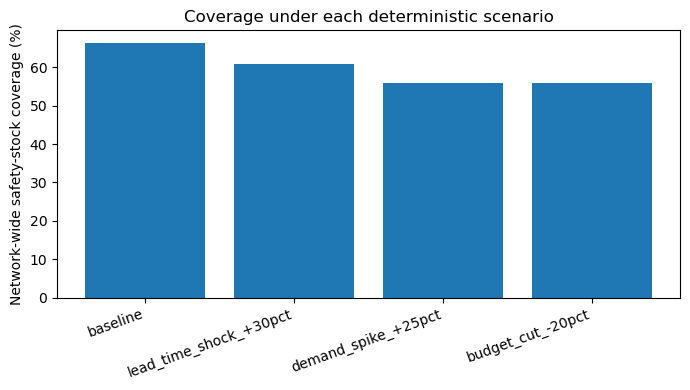

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(scenario_df["scenario"], scenario_df["coverage_pct"] * 100)
ax.set_ylabel("Network-wide safety-stock coverage (%)")
ax.set_title("Coverage under each deterministic scenario")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 7. Stochastic analysis -- Monte Carlo simulation
Compare the **current** (flat 60%-funded) policy vs. the **optimized** (PuLP-allocated) policy under 5,000 sampled draws of demand-during-lead-time uncertainty per pair. Report expected outcomes with 90% confidence intervals, not bare point estimates.

In [11]:
N_TRIALS = 5000
pair_df["baseline_ss"] = pair_df["ideal_safety_stock"] * 0.6

def monte_carlo(policy_col):
    total_stockout_events = np.zeros(N_TRIALS)
    total_cost = np.zeros(N_TRIALS)
    for _, row in pair_df.iterrows():
        sampled_dlt_demand = np.clip(np.random.normal(row["mean_dlt"], row["sigma_dlt"], N_TRIALS), 0, None)
        funded_ss = row[policy_col]
        available = row["mean_dlt"] + funded_ss
        stockout = (sampled_dlt_demand > available).astype(int)
        shortfall = np.clip(sampled_dlt_demand - available, 0, None)
        total_stockout_events += stockout
        total_cost += (
            funded_ss * (HOLDING_COST_PCT_ANNUAL / 52.0) * row["unit_cost"]
            + shortfall * STOCKOUT_PENALTY_PER_UNIT_FACTOR * (HOLDING_COST_PCT_ANNUAL / 52.0) * row["unit_cost"]
        )
    return total_stockout_events, total_cost

current_stockouts, current_cost = monte_carlo("baseline_ss")
optimized_stockouts, optimized_cost = monte_carlo("optimized_safety_stock")

def summarize(name, stockouts, cost):
    ci_low, ci_high = np.percentile(stockouts, [5, 95])
    cost_low, cost_high = np.percentile(cost, [5, 95])
    print(f"{name}:")
    print(f"  Expected stockout events/period: {stockouts.mean():.2f}  (90% CI: [{ci_low:.2f}, {ci_high:.2f}])")
    print(f"  Expected total cost/period: {cost.mean():,.0f}  (90% CI: [{cost_low:,.0f}, {cost_high:,.0f}])\n")

summarize("Current policy (flat 60% funding)", current_stockouts, current_cost)
summarize("Optimized policy (nonlinear solver)", optimized_stockouts, optimized_cost)

reduction = (1 - optimized_stockouts.mean() / current_stockouts.mean()) * 100
cost_delta = optimized_cost.mean() - current_cost.mean()
print(f"Headline: optimized policy reduces expected stockout events by {reduction:.1f}%, "
      f"at a {cost_delta:+,.0f} change in expected cost vs. current policy.")
print("This is a genuine risk/cost TRADE-OFF, not a free win -- exactly the kind of "
      "decision-under-uncertainty a client needs framed explicitly, not hidden in a single number.")

Current policy (flat 60% funding):
  Expected stockout events/period: 73.63  (90% CI: [61.00, 87.00])
  Expected total cost/period: 2,016  (90% CI: [1,890, 2,166])

Optimized policy (nonlinear solver):
  Expected stockout events/period: 55.73  (90% CI: [44.00, 67.00])
  Expected total cost/period: 2,106  (90% CI: [1,998, 2,242])

Headline: optimized policy reduces expected stockout events by 24.3%, at a +89 change in expected cost vs. current policy.
This is a genuine risk/cost TRADE-OFF, not a free win -- exactly the kind of decision-under-uncertainty a client needs framed explicitly, not hidden in a single number.


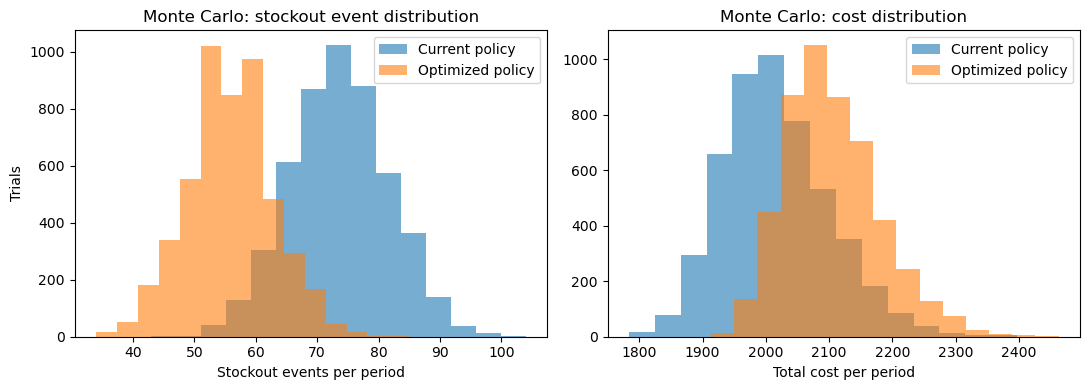

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(current_stockouts, bins=15, alpha=0.6, label="Current policy")
axes[0].hist(optimized_stockouts, bins=15, alpha=0.6, label="Optimized policy")
axes[0].set_xlabel("Stockout events per period")
axes[0].set_ylabel("Trials")
axes[0].set_title("Monte Carlo: stockout event distribution")
axes[0].legend()

axes[1].hist(current_cost, bins=15, alpha=0.6, label="Current policy")
axes[1].hist(optimized_cost, bins=15, alpha=0.6, label="Optimized policy")
axes[1].set_xlabel("Total cost per period")
axes[1].set_title("Monte Carlo: cost distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion:
- **Objective function:** minimize `holding_cost*x + stockout_penalty*(ideal_ss - x)` subject to a budget constraint and a 30% coverage floor per pair -- be able to state this from memory.
- **Why a coverage floor:** without it, a purely linear-cost LP can zero out lower-priority pairs entirely, which is mathematically "optimal" but indefensible as an actual client policy.
- **Why volume-weighted penalty, not cost-weighted:** a cost-proportional penalty cancels against the cost-proportional holding cost, leaving the LP unable to differentiate pairs at all -- an easy trap that's worth being able to explain if asked "why not just use unit cost?"
- **Why the result is a trade-off, not a clean win:** the optimized policy reduces stockouts but costs slightly more -- report this honestly with a confidence interval, and let the client's risk tolerance decide, rather than presenting a single-number "win".

---
# Power BI Export

In [13]:
import os
import numpy as np
import pandas as pd

os.makedirs("powerbi_exports", exist_ok=True)

## 1. Pair-level model output
One row per category-region pair — the core table for the Executive Summary and Policy Comparison pages.

In [14]:
export_cols = [
    "category_name", "order_region", "velocity_class", "service_level_target",
    "mean_weekly_demand", "std_weekly_demand", "mean_lead_time", "unit_cost",
    "total_qty", "sigma_dlt", "mean_dlt", "ideal_safety_stock", "reorder_point",
    "baseline_ss", "optimized_safety_stock", "funded_pct",
]
pair_export = pair_df[export_cols].copy()
pair_export["holding_cost_current"] = pair_export["baseline_ss"] * (HOLDING_COST_PCT_ANNUAL/52) * pair_export["unit_cost"]
pair_export["holding_cost_optimized"] = pair_export["optimized_safety_stock"] * (HOLDING_COST_PCT_ANNUAL/52) * pair_export["unit_cost"]
pair_export.to_csv("powerbi_exports/pair_level_model_output.csv", index=False)
print(f"Wrote {len(pair_export)} rows -> pair_level_model_output.csv")
pair_export.head()

Wrote 497 rows -> pair_level_model_output.csv


,category_name,order_region,velocity_class,service_level_target,mean_weekly_demand,std_weekly_demand,mean_lead_time,unit_cost,total_qty,sigma_dlt,mean_dlt,ideal_safety_stock,reorder_point,baseline_ss,optimized_safety_stock,funded_pct,holding_cost_current,holding_cost_optimized
0,Accessories,Canada,slow,0.95,5.111111,3.982601,2.428571,24.99,46,2.590875,1.773243,4.261610,6.034853,2.556966,3.130182,0.734507,0.245764,0.300859
1,Accessories,Caribbean,medium,0.95,6.666667,3.068659,2.720000,24.99,220,2.298948,2.590476,3.781434,6.371910,2.268860,2.770252,0.732593,0.218072,0.266264
2,Accessories,Central Africa,slow,0.95,5.230769,2.948272,2.809524,24.99,68,2.322766,2.099424,3.820610,5.920034,2.292366,2.826232,0.739733,0.220332,0.271644
3,Accessories,Central America,fast,0.99,22.805556,9.371139,2.892857,24.99,821,7.642755,9.424745,17.779708,27.204452,10.667825,9.307380,0.523483,1.025342,0.894582
4,Accessories,East Africa,slow,0.95,4.714286,3.291681,3.150000,24.99,66,2.466280,2.121429,4.056669,6.178098,2.434001,2.974638,0.733271,0.233945,0.285908


## 2. Scenario comparison
For the Scenario Analysis page.

In [15]:
scenario_df.to_csv("powerbi_exports/scenario_comparison.csv", index=False)
print(f"Wrote {len(scenario_df)} rows -> scenario_comparison.csv")
scenario_df

Wrote 4 rows -> scenario_comparison.csv


,scenario,total_ideal_ss,total_funded_ss,coverage_pct,budget
0,baseline,8270.249838,5485.206829,0.663246,483087.504242
1,lead_time_shock_+30pct,9028.775512,5489.406219,0.607990,483087.504242
2,demand_spike_+25pct,10337.812298,5775.157939,0.558644,483087.504242
3,budget_cut_-20pct,8270.249838,4620.181948,0.558651,386470.003393


## 3. Monte Carlo trial-level results
All 5,000 trials per policy — needed for the histogram visuals on the Stochastic Risk page.

In [16]:
mc_export = pd.DataFrame({
    "trial_id": np.arange(N_TRIALS),
    "current_policy_stockouts": current_stockouts,
    "current_policy_cost": current_cost,
    "optimized_policy_stockouts": optimized_stockouts,
    "optimized_policy_cost": optimized_cost,
})
mc_export.to_csv("powerbi_exports/monte_carlo_trials.csv", index=False)
print(f"Wrote {len(mc_export)} rows -> monte_carlo_trials.csv")
mc_export.head()

Wrote 5000 rows -> monte_carlo_trials.csv


,trial_id,current_policy_stockouts,current_policy_cost,optimized_policy_stockouts,optimized_policy_cost
0,0,72.0,1857.290910,48.0,2102.610254
1,1,72.0,1948.501644,56.0,2264.315959
2,2,71.0,2114.401801,52.0,2097.866891
3,3,85.0,1996.946008,62.0,2064.349128
4,4,79.0,2076.514413,45.0,2062.249990


## 4. Monte Carlo summary
Pre-aggregated KPI values (mean + 90% CI bounds) for the KPI cards — avoids making Power BI recompute percentiles over 5,000 rows on every page load.

In [17]:
mc_summary = pd.DataFrame([
    {"policy": "Current (flat 60%)", "metric": "expected_stockouts", "value": current_stockouts.mean(),
     "ci_low_90": np.percentile(current_stockouts, 5), "ci_high_90": np.percentile(current_stockouts, 95)},
    {"policy": "Current (flat 60%)", "metric": "expected_cost", "value": current_cost.mean(),
     "ci_low_90": np.percentile(current_cost, 5), "ci_high_90": np.percentile(current_cost, 95)},
    {"policy": "Optimized", "metric": "expected_stockouts", "value": optimized_stockouts.mean(),
     "ci_low_90": np.percentile(optimized_stockouts, 5), "ci_high_90": np.percentile(optimized_stockouts, 95)},
    {"policy": "Optimized", "metric": "expected_cost", "value": optimized_cost.mean(),
     "ci_low_90": np.percentile(optimized_cost, 5), "ci_high_90": np.percentile(optimized_cost, 95)},
])
mc_summary.to_csv("powerbi_exports/monte_carlo_summary.csv", index=False)
print("Wrote monte_carlo_summary.csv")
mc_summary

Wrote monte_carlo_summary.csv


,policy,metric,value,ci_low_90,ci_high_90
0,Current (flat 60%),expected_stockouts,73.626800,61.000000,87.000000
1,Current (flat 60%),expected_cost,2016.183254,1890.390742,2166.444097
2,Optimized,expected_stockouts,55.733400,44.000000,67.000000
3,Optimized,expected_cost,2105.562346,1998.184703,2242.408652


## Done
Check `powerbi_exports/` for the 4 files:
- `pair_level_model_output.csv`
- `scenario_comparison.csv`
- `monte_carlo_trials.csv`
- `monte_carlo_summary.csv`

Import all 4 into Power BI (Get Data -> Text/CSV) and follow `powerbi_build_spec.md` for the DAX measures and page layout.